In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import other_utils

In [3]:
evaluations_df = pd.read_csv('../evaluations_full_02062025.csv')

In [4]:
evaluations_df['PT'] = np.where(
    evaluations_df['pretrain'].str.contains('Not', na=False),
    'Non-PT', 'PT'
)
evaluations_df['name'] = evaluations_df['PT'] + ' ' + evaluations_df['encoding'] + ' ' + evaluations_df['trained_blocks'].astype(str) + 'L'

In [5]:
# evaluations_df[evaluations_df['n_evaluations'] > 50].drop_duplicates('Model')

In [6]:
evaluations_df[(evaluations_df['HLA'] == 'A2601')]

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,...,rmse,time,path,Model,rank_mse,rank_corr,rank_sum,pretrain,PT,name
25,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.607143,0.681327,...,1.101394,2025-05-28 09:57:47,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,10.0,8.5,18.5,Pretrained,PT,PT epitope 30L
41,A2601,Hubber,HLA,0.40,0,NaN,5.0000,15,0.225000,0.189884,...,1.426992,2025-05-28 19:19:02,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 HLA,39.0,24.5,63.5,Not Pretrained,Non-PT,Non-PT HLA 0L
103,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.600000,0.648963,...,1.093790,2025-05-28 22:52:42,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,8.0,12.0,20.0,Pretrained,PT,PT epitope 30L
178,A2601,Hubber,epitope,0.95,30,0.0001,0.0001,15,0.700000,0.803342,...,0.975368,2025-05-28 20:39:46,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,1.0,1.0,2.0,Pretrained,PT,PT epitope 30L
229,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.485714,0.598083,...,1.143873,2025-05-28 22:47:19,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,22.0,26.0,48.0,Pretrained,PT,PT epitope 30L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7225,A2601,Hubber,HLA,0.80,30,0.0001,0.0001,15,-0.017857,0.063088,...,1.556879,2025-04-23 02:25:40,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 HLA,50.0,43.0,93.0,Pretrained,PT,PT HLA 30L
7283,A2601,Hubber,HLA,0.85,30,0.0001,0.0001,15,0.185714,0.118714,...,1.405856,2025-04-23 00:33:21,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 HLA,34.0,31.0,65.0,Pretrained,PT,PT HLA 30L
7336,A2601,Hubber,epitope,0.95,30,0.0001,0.0001,15,0.578571,0.690730,...,1.123661,2025-04-23 02:23:35,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,17.0,16.0,33.0,Pretrained,PT,PT epitope 30L
7375,A2601,Hubber,epitope,0.85,30,0.0001,0.0001,15,0.607143,0.687218,...,1.017210,2025-04-23 02:28:07,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,2.0,8.5,10.5,Pretrained,PT,PT epitope 30L


(0.0, 1.0)

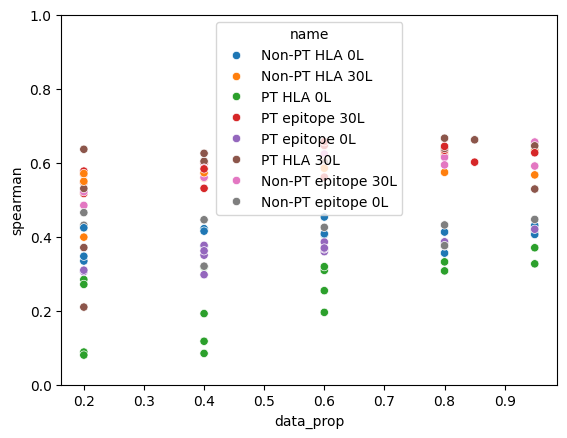

In [7]:
sns.scatterplot(data = evaluations_df[(evaluations_df['HLA'] == 'B0702')],
x = 'data_prop',
 y = 'spearman',
  hue = 'name', 
  alpha = 1)
plt.ylim([0,1])

In [8]:
evaluations_df = evaluations_df[evaluations_df['HLA'].isin(["A0201","B0702","A2601","B0801","B1801","A3001","A0101","A6801"])] #['A0201','B5701','A1101','A0301','B5101','A0206','B0702','B5101','B3501','A0101','A2402'])]

In [9]:
# keep only the needed columns and drop rows without a spearman
cols = ["HLA", "name", "path", "spearman"]
df = evaluations_df[cols].dropna(subset=["spearman"]).copy()

# top 3 per (HLA, name) by spearman
top3_df = (
    df.sort_values("spearman", ascending=False)
      .groupby(["HLA", "name"], as_index=False, group_keys=False)
      .head(3)
      .sort_values(["HLA", "name", "spearman", "path"], ascending=[True, True, False, True])
)

top3_df

,HLA,name,path,spearman
3198,A0101,Non-PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.064130
4705,A0101,Non-PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.074871
54,A0101,Non-PT HLA 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,-0.083230
2109,A0101,Non-PT HLA 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.659551
2894,A0101,Non-PT HLA 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.643287
...,...,...,...,...
2852,B1801,PT epitope 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.440559
5435,B1801,PT epitope 0L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.426573
4917,B1801,PT epitope 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.825175
3367,B1801,PT epitope 30L,/global/scratch/users/sergiomar10/losses/ESMCB...,0.797203


In [10]:
from pathlib import Path
from functools import reduce

# ---- helper: load a prediction file robustly and normalize columns ----
def _load_predictions(path):
    # 1) read
    p = str(path)
    if p.lower().endswith(".parquet"):
        df = pd.read_parquet(p)
    else:
        try:
            df = pd.read_csv(p, sep=None, engine="python")
        except Exception:
            df = pd.read_csv(p, sep="\t")

    # 2) guess identifier column
    id_candidates = [
        "epitope","Epitope","peptide","Peptide","sequence","Sequence",
        "seq","Seq","id","ID","Epitope_ID","epitope_id","uid","UID"
    ]
    id_col = next((c for c in id_candidates if c in df.columns), None)
    if id_col is None:
        # fall back to index
        df = df.reset_index().rename(columns={"index": "key"})
        id_col = "key"

    # 3) measured column
    measured_col = "measured" if "measured" in df.columns else None

    # 4) prediction column
    pred_candidates = [
        "prediction","pred","predicted","predictions","score","y_pred",
        "affinity_pred","pred_affinity","predicted_affinity",
        "logit","binding_pred","ESMCBA_prediction","MHCflurry_prediction","affinity"
    ]
    pred_col = next((c for c in pred_candidates if c in df.columns and c != measured_col), None)
    if pred_col is None:
        raise ValueError(f"No prediction column found in {path}. "
                         f"Looked for: {pred_candidates}")

    # 5) keep only needed cols and average duplicates on ID
    keep = [id_col, pred_col] + ([measured_col] if measured_col else [])
    d = df.loc[:, keep].copy()
    num_cols = [c for c in d.columns if c != id_col]
    d = d.groupby(id_col, as_index=False)[num_cols].mean()

    # 6) standardize names
    ren = {id_col: "key", pred_col: "pred"}
    if measured_col:
        ren[measured_col] = "measured"
    d = d.rename(columns=ren)

    return d  # columns: key, pred, [measured]

# ---------- main logic ----------
# expects top3_df with columns: HLA, name, path
assert {"HLA","name","path"}.issubset(top3_df.columns)

corr_by_hla_name = {}      # {(HLA, name): pandas.DataFrame corr-matrix across that group's paths}
path_vs_measured_rows = [] # list of dicts for per-path Spearman vs measured
load_errors = []

for (hla, nm), sub in top3_df.groupby(["HLA", "name"], sort=False):
    # load each path in this group
    matrices = []  # each is a 2-col df: key + one prediction column named by file
    pred_col_names = []  # keep original identity
    for path in sub["path"]:
        try:
            d = _load_predictions(path)
        except Exception as e:
            load_errors.append({"HLA": hla, "name": nm, "path": path, "error": str(e)})
            continue

        # rename pred to a unique column per path
        col_name = Path(str(path)).name  # short readable label
        pred_col_names.append((path, col_name))
        matrices.append(d[["key", "pred"]].rename(columns={"pred": col_name}))

        # per-path spearman vs measured
        if "measured" in d.columns:
            v = d[["pred", "measured"]].dropna()
            if len(v) >= 2:
                coef, pval = spearmanr(v["pred"], v["measured"])
                n = len(v)
            else:
                coef, pval, n = np.nan, np.nan, len(v)
        else:
            coef, pval, n = np.nan, np.nan, np.nan

        path_vs_measured_rows.append({
            "HLA": hla,
            "name": nm,
            "path": path,
            "spearman_vs_measured": float(coef) if pd.notna(coef) else np.nan,
            "pval": float(pval) if pd.notna(pval) else np.nan,
            "n": int(n) if pd.notna(n) else np.nan
        })

    # pairwise Spearman across all paths in this (HLA, name) group
    if len(matrices) >= 2:
        merged = reduce(lambda L, R: pd.merge(L, R, on="key", how="inner"), matrices)
        pred_cols = [c for c in merged.columns if c != "key"]
        if len(pred_cols) >= 2:
            corr = merged[pred_cols].corr(method="spearman")
            corr_by_hla_name[(hla, nm)] = corr

# tidy per-path results
path_vs_measured_df = (
    pd.DataFrame(path_vs_measured_rows)
      .sort_values(["HLA","name","spearman_vs_measured"], ascending=[True, True, False])
      .reset_index(drop=True)
)

# Examples of how to use the outputs:
# 1) correlation matrix for a specific (HLA, name):
# corr_by_hla_name.get(("HLA-A0201", "ESMCBA"))
#
# 2) per-path Spearman vs measured (with N and p-value):
# path_vs_measured_df
#
# 3) any load errors:
# pd.DataFrame(load_errors)


In [11]:
from functools import reduce

# ---- loader (same as before, returns columns: key, pred, [measured]) ----
def _load_predictions(path):
    p = str(path)
    if p.lower().endswith(".parquet"):
        df = pd.read_parquet(p)
    else:
        try:
            df = pd.read_csv(p, sep=None, engine="python")
        except Exception:
            df = pd.read_csv(p, sep="\t")

    id_candidates = [
        "epitope","Epitope","peptide","Peptide","sequence","Sequence",
        "seq","Seq","id","ID","Epitope_ID","epitope_id","uid","UID"
    ]
    id_col = next((c for c in id_candidates if c in df.columns), None)
    if id_col is None:
        df = df.reset_index().rename(columns={"index": "key"})
        id_col = "key"

    measured_col = "measured" if "measured" in df.columns else None
    pred_candidates = [
        "prediction","pred","predicted","predictions","score","y_pred",
        "affinity_pred","pred_affinity","predicted_affinity","logit",
        "binding_pred","ESMCBA_prediction","MHCflurry_prediction","affinity"
    ]
    pred_col = next((c for c in pred_candidates if c in df.columns and c != measured_col), None)
    if pred_col is None:
        raise ValueError(f"No prediction column found in file.")

    keep = [id_col, pred_col] + ([measured_col] if measured_col else [])
    d = df.loc[:, keep].copy()
    num_cols = [c for c in d.columns if c != id_col]
    d = d.groupby(id_col, as_index=False)[num_cols].mean()

    ren = {id_col: "key", pred_col: "pred"}
    if measured_col:
        ren[measured_col] = "measured"
    d = d.rename(columns=ren)
    return d  # key, pred, [measured]

# ---------- build wide table per HLA with 3 reps per name + measured ----------
def build_wide_by_hla_with_reps(top3_df):
    """
    Returns:
      wide_by_hla: {HLA: df with columns ['key', '<name> #1', '<name> #2', '<name> #3', ..., 'measured']}
      corr_by_hla: {HLA: Spearman correlation matrix across all columns except 'key'}
    """
    assert {"HLA","name","path","spearman"}.issubset(top3_df.columns)
    wide_by_hla = {}
    corr_by_hla  = {}

    for hla, sub_hla in top3_df.groupby("HLA", sort=False):
        cols = []
        measured_sources = []

        # enforce exactly the top 3 per name by spearman (in case top3_df wasn't filtered yet)
        for nm, sub_nm in (sub_hla.sort_values("spearman", ascending=False)
                                     .groupby("name", sort=False)):
            picks = list(sub_nm["path"])[:3]
            if len(picks) < 3:
                print(f"[WARN] {hla} | {nm} has {len(picks)} paths, expected 3.")

            for j, path in enumerate(picks, start=1):
                d = _load_predictions(path)
                cols.append(d[["key","pred"]].rename(columns={"pred": f"{nm} #{j}"}))
                if "measured" in d.columns:
                    measured_sources.append(d[["key","measured"]].copy())

        if not cols:
            continue

        wide = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), cols)

        # unify measured from all sources by coalescing left to right
        if measured_sources:
            ms = [m.rename(columns={"measured": f"m{i}"}) for i, m in enumerate(measured_sources)]
            mmerge = reduce(lambda L,R: pd.merge(L, R, on="key", how="outer"), ms)
            # coalesce to a single measured column (take first non-NA)
            mcols = [c for c in mmerge.columns if c != "key"]
            mmerge["measured"] = mmerge[mcols].bfill(axis=1).iloc[:, 0]
            wide = wide.merge(mmerge[["key","measured"]], on="key", how="left")

        wide_by_hla[hla] = wide

        # correlation (pairwise complete obs), include measured if present
        pred_cols = [c for c in wide.columns if c != "key"]
        corr_by_hla[hla] = wide[pred_cols].corr(method="spearman")

    return wide_by_hla, corr_by_hla

wide_by_hla, corr_by_hla = build_wide_by_hla_with_reps(top3_df)

def plot_corr_for_hla_half(corr_by_hla, hla, annotate=False, figsize=7, half="upper"):
    """
    half: "upper" to mask upper triangle, "lower" to mask lower triangle.
    """
    if hla not in corr_by_hla:
        print(f"No matrix for {hla}")
        return

    corr = corr_by_hla[hla].copy()

    # put measured first if present
    cols = list(corr.columns)
    if "measured" in cols:
        cols = ["measured"] + [c for c in cols if c != "measured"]
        corr = corr.loc[cols, cols]

    # build mask
    n = corr.shape[0]
    mask = np.zeros_like(corr, dtype=bool)
    if half == "upper":
        mask[np.triu_indices(n, k=1)] = True   # mask above diagonal
    elif half == "lower":
        mask[np.tril_indices(n, k=1)] = True   # mask below diagonal

    sns.set(style="white")
    plt.figure(figsize=(figsize, figsize))
    ax = sns.heatmap(
        corr,
        mask=mask,
        vmin=-1, vmax=1, center=0,
        cmap="vlag",
        square=True,
        cbar=True,
        annot=annotate, fmt=".2f" if annotate else "",
        linewidths=0
    )
    ax.set_title(f"HLA-{hla}", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

# example:
# plot_corr_for_hla_half(corr_by_hla, "A0201", annotate=False, figsize=7, half="upper")

In [12]:

def _order_cols_measured_first_and_group_reps(corr):
    cols = list(corr.columns)
    # put measured first if present
    if "measured" in cols:
        cols.remove("measured")
        ordered = ["measured"]
    else:
        ordered = []

    # group base names and sort reps as #1,#2,#3
    # base name is everything before " #<num>"
    base2reps = {}
    for c in cols:
        m = re.match(r"^(.*)\s+#(\d+)$", c)
        if m:
            base, rep = m.group(1), int(m.group(2))
        else:
            base, rep = c, 999  # if not a replicate label, push to end
        base2reps.setdefault(base, []).append((rep, c))

    # keep stable order by the first occurrence in cols
    seen_base = []
    for c in cols:
        base = re.match(r"^(.*)\s+#\d+$", c)
        base = base.group(1) if base else c
        if base not in seen_base:
            seen_base.append(base)

    for base in seen_base:
        reps = sorted(base2reps[base], key=lambda x: x[0])
        ordered.extend([c for _, c in reps])

    # ensure all are present and unique
    ordered = [c for c in ordered if c in corr.columns]
    return ordered

def plot_hla_grid_lower_triangle(corr_by_hla, hlas, ncols=2, figsize_per_panel=4.0,
                                 annotate=False, save_path=None, dpi=300):
    """
    corr_by_hla: dict {HLA: corr-matrix DataFrame}
    hlas: list of HLA strings to plot
    """
    sns.set(style="white")
    hlas = [h for h in hlas if h in corr_by_hla]
    if not hlas:
        print("No matching HLAs to plot.")
        return

    n = len(hlas)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20,35),
                             squeeze=False)

    vmin, vmax = -1.0, 1.0
    norm = Normalize(vmin=vmin, vmax=vmax)
    mappable = ScalarMappable(norm=norm, cmap="vlag")
    mappable.set_array([])

    k = 0
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r][c]
            if k >= n:
                ax.axis("off")
                continue

            hla = hlas[k]
            corr = corr_by_hla[hla].copy()
            # reorder columns: measured first, then groups of name #1..#3
            ordered = _order_cols_measured_first_and_group_reps(corr)
            corr = corr.loc[ordered, ordered]

            # mask upper triangle (keep diagonal)
            m = np.zeros_like(corr, dtype=bool)
            m[np.triu_indices_from(m, k=1)] = True

            sns.heatmap(corr, mask=m, cmap="vlag", vmin=vmin, vmax=vmax, center=0,
                        square=True, cbar=False, ax=ax,
                        annot=annotate, fmt=".2f" if annotate else "",
                        linewidths=0)

            ax.set_title(hla, fontsize=11)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
            k += 1

    # shared colorbar
    cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(),
                        fraction=0.025, pad=-0.2)
    cbar.set_label("Spearman ρ", fontsize=10)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_1543463/35363849.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


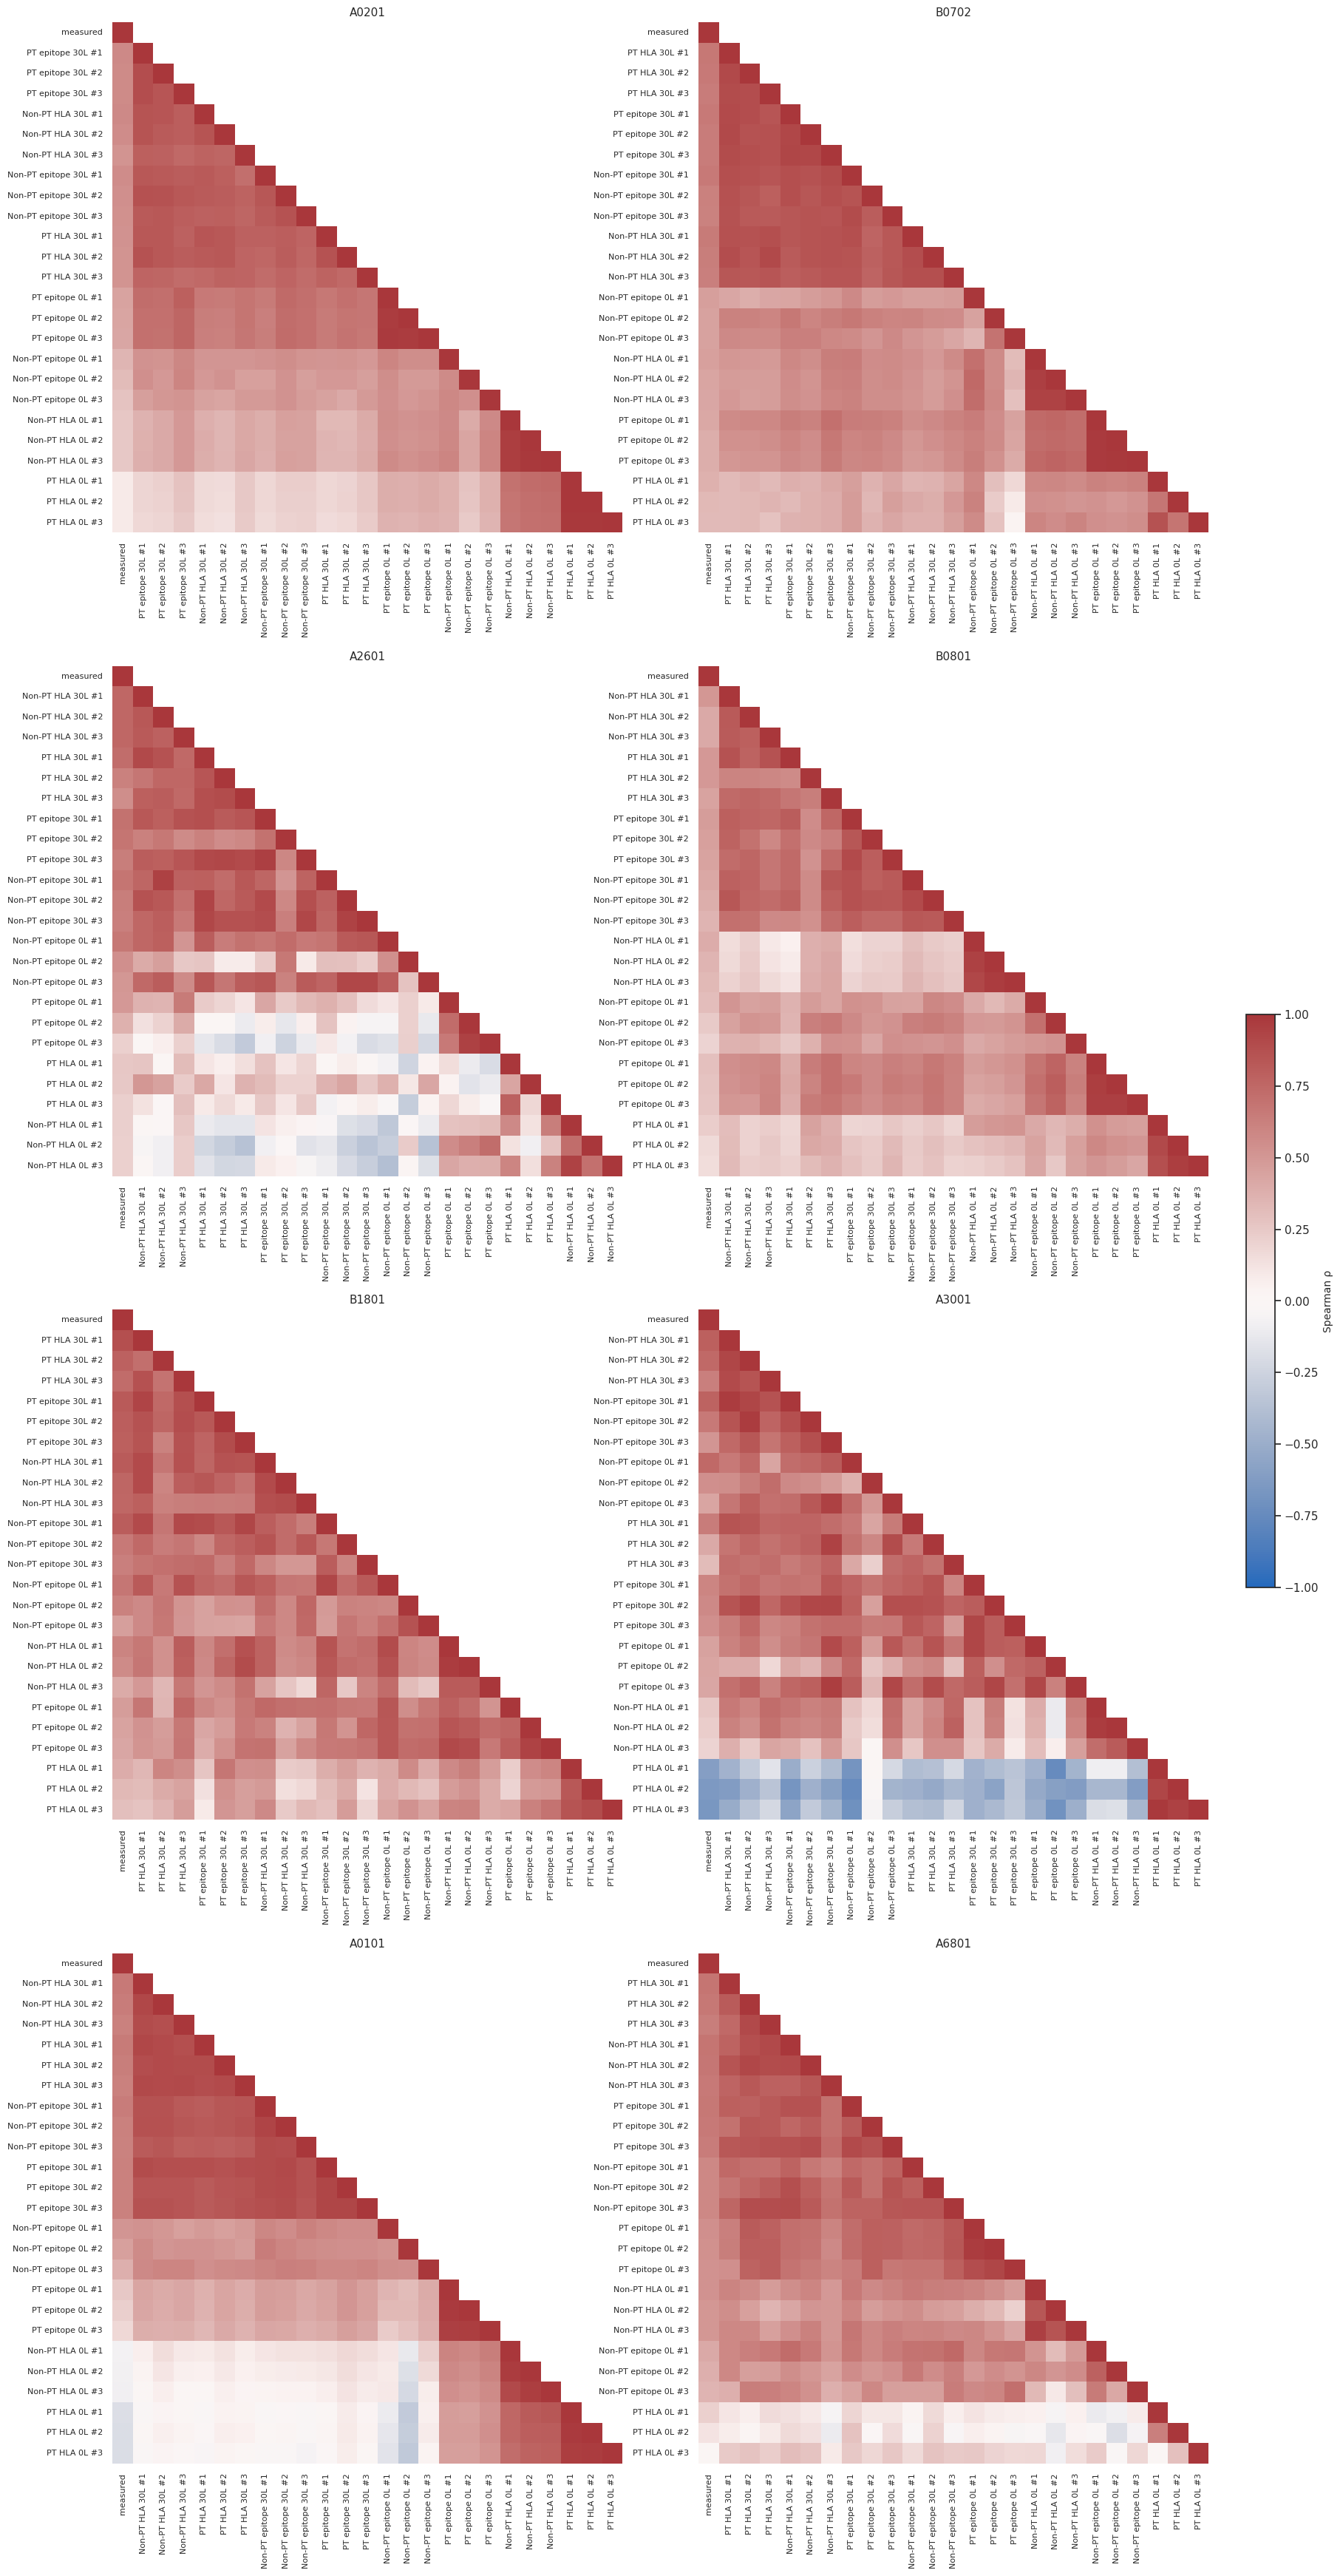

In [13]:
import math
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import re

target_hlas = ["A0201","B0702","A2601","B0801","B1801","A3001","A0101","A6801"]
plot_hla_grid_lower_triangle(corr_by_hla, target_hlas, ncols=2, figsize_per_panel=2.2,
                             annotate=False, save_path="corr_name_reps_grid.png", dpi=300)


/tmp/ipykernel_1543463/309708673.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_tbl = (plot_df.groupby(['name','bin'])[metric_col]
/tmp/ipykernel_1543463/309708673.py:42: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_1543463/309708673.py:42: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


                  name        bin      mean       sem  n
0        Non-PT HLA 0L      0–500  0.211081  0.077211  7
1        Non-PT HLA 0L   500–1000       NaN       NaN  0
2        Non-PT HLA 0L  1000–2000       NaN       NaN  0
3        Non-PT HLA 0L  2000–7000  0.236630       NaN  1
4       Non-PT HLA 30L      0–500  0.517942  0.047894  7
5       Non-PT HLA 30L   500–1000       NaN       NaN  0
6       Non-PT HLA 30L  1000–2000       NaN       NaN  0
7       Non-PT HLA 30L  2000–7000  0.514554       NaN  1
8    Non-PT epitope 0L      0–500  0.302742  0.034797  7
9    Non-PT epitope 0L   500–1000       NaN       NaN  0
10   Non-PT epitope 0L  1000–2000       NaN       NaN  0
11   Non-PT epitope 0L  2000–7000  0.207185       NaN  1
12  Non-PT epitope 30L      0–500  0.518669  0.036603  7
13  Non-PT epitope 30L   500–1000       NaN       NaN  0
14  Non-PT epitope 30L  1000–2000       NaN       NaN  0
15  Non-PT epitope 30L  2000–7000  0.515261       NaN  1
16           PT HLA 0L      0–5

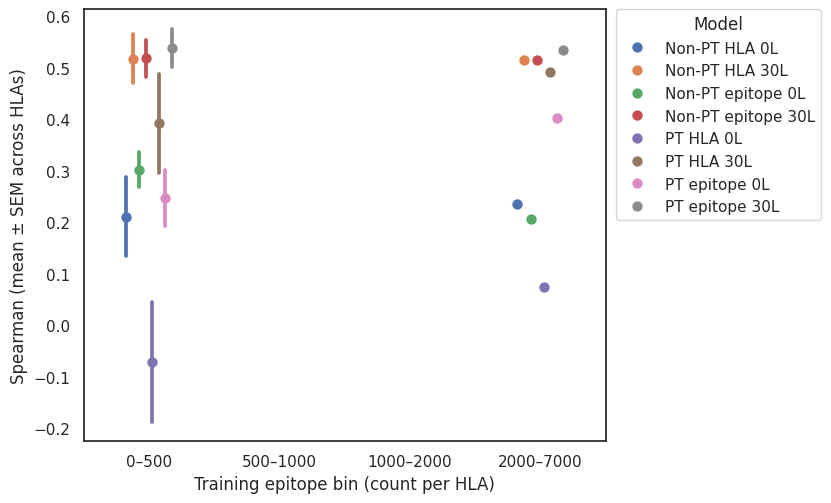

In [14]:
# ---- config ----
metric_col = 'spearman'   # change if you want a different metric

# ---- load HLA sizes and prep bins ----
ba_sizes = pd.read_csv('../../data/summary_BA_dataset.csv')[['HLA','n_train_epitopes']].copy()

def _norm_hla(h):
    s = str(h).upper().replace(' ', '').replace('*','').replace(':','').replace('-','')
    return s if s.startswith('HLA') else 'HLA' + s

ba_sizes['HLA_norm'] = ba_sizes['HLA'].map(_norm_hla)

bins   = [0,500, 1000, 2000, 7000]
labels = ['0–500', '500–1000', '1000–2000', '2000–7000']
ba_sizes['bin'] = pd.cut(ba_sizes['n_train_epitopes'], bins=bins, labels=labels, right=False)

# ---- collapse evaluations to one value per HLA per model ----
eval_clean = (evaluations_df.dropna(subset=['HLA','name', metric_col])
                              .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla)))

per_hla_model = (eval_clean.groupby(['HLA_norm','name'], as_index=False)[metric_col]
                         .mean())   # mean over runs for that HLA+model

# ---- join sizes -> assign bins ----
plot_df = (per_hla_model.merge(ba_sizes[['HLA_norm','bin']], on='HLA_norm', how='left')
                        .dropna(subset=['bin']))

# optional: make bin order stable
plot_df['bin'] = pd.Categorical(plot_df['bin'], categories=labels, ordered=True)

# ---- summary table (mean ± SEM across HLAs in each bin x model) ----
summary_tbl = (plot_df.groupby(['name','bin'])[metric_col]
                      .agg(mean='mean', sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)), n='size')
                      .reset_index()
                      .sort_values(['name','bin']))

print(summary_tbl.head(20))

# ---- plot: mean ± SEM per bin, hue=model ----
fig, ax = plt.subplots(figsize=(8.5, 5.2))

sns.pointplot(
    data=plot_df,
    x='bin', y=metric_col, hue='name',
    errorbar='se', dodge=0.35, join=False, markers='o', scale=1.0, ax=ax
)

# cosmetics
ax.set_xlabel('Training epitope bin (count per HLA)')
ax.set_ylabel(f'{metric_col.capitalize()} (mean ± SEM across HLAs)')
ax.grid(False)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()


In [15]:
# --- load the richer BA summary table ---
ba_datasets = pd.read_csv('../../data/table_summary_BA_data.csv')

def _norm_hla(h):
    s = str(h).upper().replace(' ', '').replace('*','').replace(':','').replace('-','')
    return s if s.startswith('HLA') else 'HLA' + s

# normalize and make optional bins
bins   = [0, 500, 1000, 2000, 7000]
labels = ['0–500', '500–1000', '1000–2000', '2000–7000']

ba_datasets = ba_datasets.assign(
    HLA_norm = lambda d: d['HLA'].map(_norm_hla),
    train_bin = lambda d: pd.cut(d['n_train_epitopes'], bins=bins, labels=labels, right=False),
    eval_bin  = lambda d: pd.cut(d['n_eval_epitopes'],  bins=bins, labels=labels, right=False),
)

ba_ds_clean = ba_datasets[['HLA_norm','n_train_epitopes','n_eval_epitopes','train_bin','eval_bin']].drop_duplicates('HLA_norm')

# --- helper to summarize any eval table to per-HLA × model, then attach counts ---
def summarize_per_hla(df, metric_col='spearman'):
    return (df.dropna(subset=['HLA','name', metric_col])
              .assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla))
              .groupby(['HLA_norm','name'])[metric_col]
              .agg(mean='mean',
                   std=lambda x: x.std(ddof=1),
                   sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)),
                   n='size')
              .reset_index())

# A) all runs -> attach train/eval counts
summary_all = summarize_per_hla(evaluations_df, metric_col='spearman')
summary_all = (summary_all
               .merge(ba_ds_clean, on='HLA_norm', how='left')
               .loc[:, ['HLA_norm','n_train_epitopes','n_eval_epitopes','train_bin','eval_bin',
                        'name','mean','std','sem','n']]
               .sort_values(['name','HLA_norm'])
               .reset_index(drop=True))

# B) only the top-3 paths per (HLA, name) -> attach train/eval counts
top3_keys = top3_df[['HLA','name','path']].drop_duplicates()
eval_top3_only = evaluations_df.merge(top3_keys, on=['HLA','name','path'], how='inner')

summary_top3 = summarize_per_hla(eval_top3_only, metric_col='spearman')
summary_top3 = (summary_top3
                .merge(ba_ds_clean, on='HLA_norm', how='left')
                .loc[:, ['HLA_norm','n_train_epitopes','n_eval_epitopes','train_bin','eval_bin',
                         'name','mean','std','sem','n']]
                .sort_values(['name','HLA_norm'])
                .reset_index(drop=True))

# quick peek
print("All runs:")
print(summary_all.head(12))
print("\nTop-3 only:")
print(summary_top3.head(12))


All runs:
    HLA_norm  n_train_epitopes  n_eval_epitopes  train_bin  eval_bin  \
0   HLAA0101               338              128      0–500     0–500   
1   HLAA0201              6714              518  2000–7000  500–1000   
2   HLAA2601                95               17      0–500     0–500   
3   HLAA3001                24               10      0–500     0–500   
4   HLAA6801               334               39      0–500     0–500   
5   HLAB0702               449              115      0–500     0–500   
6   HLAB0801                96               53      0–500     0–500   
7   HLAB1801                40               12      0–500     0–500   
8   HLAA0101               338              128      0–500     0–500   
9   HLAA0201              6714              518  2000–7000  500–1000   
10  HLAA2601                95               17      0–500     0–500   
11  HLAA3001                24               10      0–500     0–500   

              name      mean       std       sem   n 

In [16]:
import pandas as pd
import numpy as np

# --- helpers ---
def _norm_hla(h):
    s = str(h).upper().replace(' ', '').replace('*','').replace(':','').replace('-','')
    return s if s.startswith('HLA') else 'HLA' + s

# --- load HLA-level sizes with train and eval ---
ba_datasets = pd.read_csv('../../data/table_summary_BA_data.csv')
ba_datasets = ba_datasets.assign(HLA_norm=lambda d: d['HLA'].map(_norm_hla))
ba_counts = ba_datasets[['HLA_norm','n_train_epitopes','n_eval_epitopes']].drop_duplicates('HLA_norm')

# --- prepare runs and merge ---
runs = evaluations_df.copy()
runs['HLA_norm'] = runs['HLA'].map(_norm_hla)

# make sure these are numeric
for c in ['data_prop','spearman','pearsonr','rmse']:
    if c in runs.columns:
        runs[c] = pd.to_numeric(runs[c], errors='coerce')

merged_runs = (
    runs.merge(ba_counts, on='HLA_norm', how='left')
        .assign(
            data_prop = lambda d: d['data_prop'].clip(lower=0, upper=1),
            n_train_used = lambda d: (d['data_prop'] * d['n_train_epitopes']).round().astype('Int64'),
            data_used_pct = lambda d: (d['data_prop'] * 100).round(2).astype('Float64')
        )
)

# optional: show a clean column order if present
cols_show = [
    'HLA','HLA_norm','name','pretrain','PT','encoding','Losses',
    'data_prop','data_used_pct','n_train_epitopes','n_train_used','n_eval_epitopes',
    'trained_blocks','lr_transformer','lr_regression','n_evaluations',
    'spearman','pearsonr','rmse','rank_mse','rank_corr','rank_sum',
    'Model','time','path'
]
merged_runs = merged_runs[[c for c in cols_show if c in merged_runs.columns]]

# quick sanity check for missing size info
missing_sizes = merged_runs[merged_runs['n_train_epitopes'].isna()]['HLA'].dropna().unique().tolist()
if missing_sizes:
    print("No train/eval counts for these HLAs:", missing_sizes)

print(merged_runs.head(12))


      HLA  HLA_norm                name        pretrain      PT encoding  \
0   A6801  HLAA6801          PT HLA 30L      Pretrained      PT      HLA   
1   A2601  HLAA2601      PT epitope 30L      Pretrained      PT  epitope   
2   A6801  HLAA6801      PT epitope 30L      Pretrained      PT  epitope   
3   A3001  HLAA3001   Non-PT epitope 0L  Not Pretrained  Non-PT  epitope   
4   A3001  HLAA3001       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
5   A2601  HLAA2601       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
6   A0101  HLAA0101       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
7   B1801  HLAB1801       Non-PT HLA 0L  Not Pretrained  Non-PT      HLA   
8   A0201  HLAA0201       PT epitope 0L      Pretrained      PT  epitope   
9   A0101  HLAA0101  Non-PT epitope 30L  Not Pretrained  Non-PT  epitope   
10  A6801  HLAA6801  Non-PT epitope 30L  Not Pretrained  Non-PT  epitope   
11  A3001  HLAA3001  Non-PT epitope 30L  Not Pretrained  Non-PT  epitope   

    Losses 

In [17]:
pd.set_option('display.max_columns', 50)

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import t as t_dist

# =========================
# Configuration
# =========================
# Bin configuration
BIN_EDGES_COMPACT = [0, 200, 1000, 10**9]
BIN_LABELS_COMPACT = ["<200", "200-1000", "1000+"]

SHOW_MODE = "sem"  # "sem" -> mean ± SEM, "ci" -> mean [95% CI]

# =========================
# Helper Functions
# =========================
def _norm_hla(h):
    """Normalize HLA names for consistent matching."""
    s = str(h).upper().replace(" ", "").replace("*", "").replace(":", "").replace("-", "")
    return s if s.startswith("HLA") else "HLA" + s

def _pt_label(row):
    """Extract pretrain label."""
    v = row.get("PT", row.get("pretrain", ""))
    v = str(v).strip().lower()
    if v.startswith(("not", "non")):
        return "Non-PT"
    elif v in ("pt", "pretrained") or v.startswith("pre"):
        return "PT"
    return "PT"

def _enc_label(row):
    """Extract encoding label: E for epitope, H for HLA."""
    return "E" if str(row.get("encoding", "")).strip().lower() == "epitope" else "H"

def _layers_label(x):
    """Convert trained_blocks to 0L or 30L."""
    try:
        t = int(float(x)) if pd.notna(x) else 0
    except Exception:
        t = 0
    return "30L" if t >= 30 else "0L"

def agg_stat_per_hla_model_bin(df, value_col):
    """
    Calculate mean, SEM, and 95% CI per HLA per model per bin combination.
    This gives us uncertainty within each HLA×model×bin cell across different runs/seeds.
    """
    # Group by HLA, model, and bin - compute stats across multiple runs/seeds
    g = df.groupby(["HLA_norm", "enc_label", "row_label", "bin"], observed=True)[value_col]
    stats = g.agg(mean="mean", n="size", sd=lambda x: x.std(ddof=1)).reset_index()
    
    # Calculate SEM (NaN when n <= 1)
    stats["sem"] = stats.apply(lambda r: r["sd"] / np.sqrt(r["n"]) if r["n"] > 1 else np.nan, axis=1)
    
    # Calculate 95% CI half-width
    hw = np.full(len(stats), np.nan, dtype=float)
    ok = stats["n"] > 1
    if ok.any():
        tcrit = t_dist.ppf(0.975, df=(stats.loc[ok, "n"] - 1))
        hw[ok.values] = tcrit * stats.loc[ok, "sem"].values
    stats["ci95"] = hw
    
    return stats.drop(columns="sd")

def aggregate_across_hlas(df, value_col="mean"):
    """
    After getting per-HLA stats, aggregate across HLAs for each model×bin combination.
    """
    g = df.groupby(["enc_label", "row_label", "bin"], observed=True)[value_col]
    out = g.agg(mean="mean", n="size", sd=lambda x: x.std(ddof=1)).reset_index()
    
    # Calculate SEM and CI across HLAs
    out["sem"] = out.apply(lambda r: r["sd"] / np.sqrt(r["n"]) if r["n"] > 1 else np.nan, axis=1)
    
    hw = np.full(len(out), np.nan, dtype=float)
    ok = out["n"] > 1
    if ok.any():
        tcrit = t_dist.ppf(0.975, df=(out.loc[ok, "n"] - 1))
        hw[ok.values] = tcrit * out.loc[ok, "sem"].values
    out["ci95"] = hw
    
    return out.drop(columns="sd")

def make_block(stats_rho, stats_r, enc, labels=BIN_LABELS_COMPACT, show="sem"):
    """
    Create formatted block for either E or H models.
    """
    r1 = stats_rho[stats_rho["enc_label"] == enc].copy()
    r2 = stats_r[stats_r["enc_label"] == enc].copy()
    
    def fmt_row(mean, sem, ci, n_hlas=None):
        if pd.isna(mean):
            return ""
        if pd.isna(sem) or pd.isna(ci):
            return f"{mean:.3f}"  # Just mean when no CI available
        
        if show == "sem":
            base = f"{mean:.3f} ± {sem:.3f}"
        else:
            base = f"{mean:.3f} [{(mean-ci):.3f}, {(mean+ci):.3f}]"
        
        # Add n_HLAs info if available
        if pd.notna(n_hlas) and n_hlas > 0:
            base += f" (n={int(n_hlas)})"
        
        return base
    
    r1["rho_fmt"] = [fmt_row(m, s, c, n) for m, s, c, n in zip(r1["mean"], r1["sem"], r1["ci95"], r1.get("n", np.nan))]
    r2["r_fmt"] = [fmt_row(m, s, c, n) for m, s, c, n in zip(r2["mean"], r2["sem"], r2["ci95"], r2.get("n", np.nan))]
    
    piv_rho = r1.pivot(index="row_label", columns="bin", values="rho_fmt")
    piv_r = r2.pivot(index="row_label", columns="bin", values="r_fmt")
    
    # Interleave rho and r columns for each bin
    cols = []
    data = {}
    for b in labels:
        cols.extend([f"rho_{b}", f"r_{b}"])
        data[f"rho_{b}"] = piv_rho.get(b, pd.Series(index=piv_rho.index, dtype=object))
        data[f"r_{b}"] = piv_r.get(b, pd.Series(index=piv_r.index, dtype=object))
    
    block = pd.DataFrame(data, index=piv_rho.index)
    
    # Order rows consistently
    row_order_E = ["Non-PT E 0L", "Non-PT E 30L", "PT E 0L", "PT E 30L"]
    row_order_H = ["Non-PT H 0L", "Non-PT H 30L", "PT H 0L", "PT H 30L"]
    block = block.reindex(row_order_E if enc == "E" else row_order_H)
    
    return block

def to_latex_table_compact_combined(E_block, H_block, labels=BIN_LABELS_COMPACT, outfile=None):
    """
    Generate compact combined LaTeX table with both E and H models.
    """
    bins_header = " & ".join([f"\\multicolumn{{2}}{{c}}{{{b}}}" for b in labels])
    sub_header = " & " + " & ".join(sum([["$\\rho$", "$r$"] for _ in labels], [])) + r" \\"
    
    def rows(df):
        lines = []
        for idx, row in df.fillna("").iterrows():
            clean_idx = idx.replace(" E ", " E ").replace(" H ", " H ")
            cells = [clean_idx] + [row[c] for c in df.columns]
            lines.append(" & ".join(cells) + r" \\")
        return "\n".join(lines)
    
    ncols = 1 + 2 * len(labels)
    tex = f"""\\begin{{table}}[ht]
\\centering
\\caption{{Mean Spearman $\\rho$ and Pearson $r$ with uncertainty across HLAs by model and scaled training-set size. Values show mean ± SEM (n=number of HLAs).}}
\\small
\\begin{{tabular}}{{l{'r'*(ncols-1)}}}
\\toprule
 & {bins_header} \\\\
\\midrule
Model & {sub_header}
\\multicolumn{{{ncols}}}{{l}}{{\\textbf{{Epitope-only (E) Models}}}} \\\\
{rows(E_block)}
\\addlinespace
\\multicolumn{{{ncols}}}{{l}}{{\\textbf{{HLA+Epitope (H) Models}}}} \\\\
{rows(H_block)}
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
    if outfile:
        with open(outfile, "w") as f:
            f.write(tex)
    return tex

# =========================
# Main Processing Pipeline
# =========================
def create_binned_table_from_merged(merged_runs):
    """
    Main function to process merged_runs and create binned table.
    
    Parameters:
    -----------
    merged_runs : pd.DataFrame
        Should contain columns: HLA, n_train_used, spearman, pearsonr, encoding, 
        pretrain (or PT), trained_blocks, lr_transformer, lr_regression
    """
    
    print("Starting table generation from merged_runs...")
    
    # Filter for specific learning rates
    runs = merged_runs.copy()
    print(f"Initial runs: {len(runs)}")
    
    # Filter learning rates
    runs 
    print(f"After LR filtering (lr_transformer=0.0001, lr_regression=0.0001): {len(runs)}")
    
    # Normalize HLA names
    runs["HLA_norm"] = runs["HLA"].map(_norm_hla)
    
    # Convert n_train_used to numeric
    runs["n_train_used"] = pd.to_numeric(runs["n_train_used"], errors="coerce")
    
    # Create compact bins based on n_train_used
    runs["bin"] = pd.cut(
        runs["n_train_used"],
        bins=BIN_EDGES_COMPACT,
        labels=BIN_LABELS_COMPACT,
        right=False
    )
    runs["bin"] = pd.Categorical(runs["bin"], categories=BIN_LABELS_COMPACT, ordered=True)
    
    # Create model labels
    runs["PT_label"] = runs.apply(_pt_label, axis=1)
    runs["enc_label"] = runs.apply(_enc_label, axis=1)
    runs["L_label"] = runs["trained_blocks"].apply(_layers_label)
    runs["row_label"] = runs["PT_label"] + " " + runs["enc_label"] + " " + runs["L_label"]
    
    # Convert scores to numeric
    runs["spearman"] = pd.to_numeric(runs["spearman"], errors="coerce")
    runs["pearsonr"] = pd.to_numeric(runs["pearsonr"], errors="coerce")
    
    # Remove rows with missing essential data
    runs_clean = runs.dropna(subset=["bin", "spearman", "pearsonr", "HLA_norm"]).copy()
    print(f"After removing missing data: {len(runs_clean)}")
    
    # Show data distribution
    print("\nData distribution:")
    print("By bin:")
    print(runs_clean.groupby("bin", observed=True).agg({
        "HLA_norm": "nunique", 
        "spearman": "count"
    }).rename(columns={"HLA_norm": "n_HLAs", "spearman": "n_runs"}))
    
    print("\nBy model:")
    print(runs_clean.groupby("row_label").agg({
        "HLA_norm": "nunique",
        "spearman": "count"
    }).rename(columns={"HLA_norm": "n_HLAs", "spearman": "n_runs"}))
    
    # Step 1: Calculate stats per HLA×model×bin (across different runs/seeds)
    print("\nCalculating per-HLA×model×bin statistics...")
    per_hla_stats_rho = agg_stat_per_hla_model_bin(runs_clean, "spearman")
    per_hla_stats_r = agg_stat_per_hla_model_bin(runs_clean, "pearsonr")
    
    # Step 2: Aggregate across HLAs for each model×bin
    print("Aggregating across HLAs...")
    final_stats_rho = aggregate_across_hlas(per_hla_stats_rho, "mean")
    final_stats_r = aggregate_across_hlas(per_hla_stats_r, "mean")
    
    # Build formatted blocks
    print("Building formatted table blocks...")
    E_block = make_block(final_stats_rho, final_stats_r, enc="E", show=SHOW_MODE)
    H_block = make_block(final_stats_rho, final_stats_r, enc="H", show=SHOW_MODE)
    
    # Generate LaTeX table
    latex_table = to_latex_table_compact_combined(
        E_block, H_block, 
        labels=BIN_LABELS_COMPACT, 
        outfile="table1_merged_runs_compact.tex"
    )
    
    print(f"\nGenerated compact table with bins: {BIN_LABELS_COMPACT}")
    print(f"Wrote LaTeX table to: table1_merged_runs_compact.tex")
    print(f"\nInterpretation:")
    print(f"- Values show mean ± SEM across HLAs")
    print(f"- (n=X) indicates number of HLAs contributing to that cell")
    print(f"- CI computed per HLA×model×bin, then averaged across HLAs")
    
    return {
        "E_block": E_block,
        "H_block": H_block,
        "per_hla_stats": {"rho": per_hla_stats_rho, "r": per_hla_stats_r},
        "final_stats": {"rho": final_stats_rho, "r": final_stats_r},
        "latex_table": latex_table,
        "runs_used": runs_clean
    }

# Usage:
results = create_binned_table_from_merged(merged_runs)

Starting table generation from merged_runs...
Initial runs: 842
After LR filtering (lr_transformer=0.0001, lr_regression=0.0001): 842
After removing missing data: 842

Data distribution:
By bin:
          n_HLAs  n_runs
bin                     
<200           7     568
200-1000       3     181
1000+          1      93

By model:
              n_HLAs  n_runs
row_label                   
Non-PT E 0L        8      80
Non-PT E 30L       8      80
Non-PT H 0L        8     109
Non-PT H 30L       8      93
PT E 0L            8     115
PT E 30L           8     138
PT H 0L            8     120
PT H 30L           8     107

Calculating per-HLA×model×bin statistics...
Aggregating across HLAs...
Building formatted table blocks...

Generated compact table with bins: ['<200', '200-1000', '1000+']
Wrote LaTeX table to: table1_merged_runs_compact.tex

Interpretation:
- Values show mean ± SEM across HLAs
- (n=X) indicates number of HLAs contributing to that cell
- CI computed per HLA×model×bin, then av

In [25]:
merged_runs

,HLA,HLA_norm,name,pretrain,PT,encoding,Losses,data_prop,data_used_pct,n_train_epitopes,n_train_used,n_eval_epitopes,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,rmse,rank_mse,rank_corr,rank_sum,Model,time,path
0,A6801,HLAA6801,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.60,60.0,334,200,39,30,0.0001,0.0001,39,0.604590,0.682397,0.987501,8.0,11.0,19.0,A6801 HLA,2025-05-28 21:48:33,/global/scratch/users/sergiomar10/losses/ESMCB...
1,A2601,HLAA2601,PT epitope 30L,Pretrained,PT,epitope,Hubber,0.40,40.0,95,38,17,30,0.0001,0.0001,15,0.607143,0.681327,1.101394,10.0,8.5,18.5,A2601 epitope,2025-05-28 09:57:47,/global/scratch/users/sergiomar10/losses/ESMCB...
2,A6801,HLAA6801,PT epitope 30L,Pretrained,PT,epitope,Hubber,0.20,20.0,334,67,39,30,0.0001,0.0001,39,0.579462,0.625848,1.130070,25.0,17.0,42.0,A6801 epitope,2025-05-28 22:06:21,/global/scratch/users/sergiomar10/losses/ESMCB...
3,A3001,HLAA3001,Non-PT epitope 0L,Not Pretrained,Non-PT,epitope,Hubber,0.95,95.0,24,23,10,0,NaN,5.0000,10,0.742387,0.508496,1.082574,17.0,2.0,19.0,A3001 epitope,2025-05-28 13:36:28,/global/scratch/users/sergiomar10/losses/ESMCB...
4,A3001,HLAA3001,Non-PT HLA 0L,Not Pretrained,Non-PT,HLA,Hubber,0.40,40.0,24,10,10,0,NaN,5.0000,10,0.128844,0.166571,1.890952,51.0,21.5,72.5,A3001 HLA,2025-05-28 19:59:17,/global/scratch/users/sergiomar10/losses/ESMCB...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,B1801,HLAB1801,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.95,95.0,40,38,12,30,0.0001,0.0001,12,0.678322,0.886293,2.167188,50.0,15.0,65.0,B1801 HLA,2025-04-23 03:00:38,/global/scratch/users/sergiomar10/losses/ESMCB...
838,B1801,HLAB1801,PT epitope 30L,Pretrained,PT,epitope,Hubber,0.95,95.0,40,38,12,30,0.0001,0.0001,12,0.636364,0.837717,1.112490,4.0,14.0,18.0,B1801 epitope,2025-04-23 03:07:38,/global/scratch/users/sergiomar10/losses/ESMCB...
839,B0801,HLAB0801,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.80,80.0,96,77,53,30,0.0001,0.0001,53,0.408060,0.555044,0.980667,11.0,9.0,20.0,B0801 HLA,2025-04-23 00:47:31,/global/scratch/users/sergiomar10/losses/ESMCB...
840,A0101,HLAA0101,PT HLA 30L,Pretrained,PT,HLA,Hubber,0.95,95.0,338,321,128,30,0.0001,0.0001,128,0.648864,0.703042,1.578514,8.0,2.0,10.0,A0101 HLA,2025-04-23 02:51:17,/global/scratch/users/sergiomar10/losses/ESMCB...


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ensure seaborn is up-to-date (run in terminal if needed: pip install --upgrade seaborn)
print(f"Seaborn version: {sns.__version__}")

# Bin sizes
bins = [0, 500, 1000, 2000, 4000, np.inf]
labels = ['<500', '500–1000', '1000–2000', '2000–4000', '>4000']
merged_runs['size_bin'] = pd.cut(merged_runs['n_train_used'], bins=bins, labels=labels)

# Create a group label with updated naming convention
merged_runs['group_label'] = (
    merged_runs['pretrain'].map({True: 'PT', False: 'Non-PT'}) + ' ' +
    merged_runs['encoding'].map({'HLA': 'H', 'Epitope': 'E'}) + ' ' +
    merged_runs['trained_blocks'].map({0: '0L', 30: '30L'})
)

# Verify group_label values
print("Unique group labels:", merged_runs['group_label'].unique())

Seaborn version: 0.13.2
Unique group labels: [nan]


In [ ]:
merged_runs[merged_runs['HLA'] == 'A0206']

,HLA,HLA_norm,name,pretrain,PT,encoding,Losses,data_prop,data_used_pct,n_train_epitopes,n_train_used,n_eval_epitopes,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,rmse,rank_mse,rank_corr,rank_sum,Model,time,path,size_bin,group_label


In [37]:
evaluations_df

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model,rank_mse,rank_corr,rank_sum,pretrain,PT,name
6,A6801,Hubber,HLA,0.60,30,0.0001,0.0001,39,0.604590,0.682397,0.975159,0.770937,0.460428,0.987501,2025-05-28 21:48:33,/global/scratch/users/sergiomar10/losses/ESMCB...,A6801 HLA,8.0,11.0,19.0,Pretrained,PT,PT HLA 30L
25,A2601,Hubber,epitope,0.40,30,0.0001,0.0001,15,0.607143,0.681327,1.213069,0.934221,0.349155,1.101394,2025-05-28 09:57:47,/global/scratch/users/sergiomar10/losses/ESMCB...,A2601 epitope,10.0,8.5,18.5,Pretrained,PT,PT epitope 30L
28,A6801,Hubber,epitope,0.20,30,0.0001,0.0001,39,0.579462,0.625848,1.277059,0.991376,0.293382,1.130070,2025-05-28 22:06:21,/global/scratch/users/sergiomar10/losses/ESMCB...,A6801 epitope,25.0,17.0,42.0,Pretrained,PT,PT epitope 30L
31,A3001,Hubber,epitope,0.95,0,NaN,5.0000,10,0.742387,0.508496,1.171966,0.879813,-0.643877,1.082574,2025-05-28 13:36:28,/global/scratch/users/sergiomar10/losses/ESMCB...,A3001 epitope,17.0,2.0,19.0,Not Pretrained,Non-PT,Non-PT epitope 0L
38,A3001,Hubber,HLA,0.40,0,NaN,5.0000,10,0.128844,0.166571,3.575699,1.697611,-4.015515,1.890952,2025-05-28 19:59:17,/global/scratch/users/sergiomar10/losses/ESMCB...,A3001 HLA,51.0,21.5,72.5,Not Pretrained,Non-PT,Non-PT HLA 0L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7456,B1801,Hubber,HLA,0.95,30,0.0001,0.0001,12,0.678322,0.886293,4.696705,1.794231,-0.656085,2.167188,2025-04-23 03:00:38,/global/scratch/users/sergiomar10/losses/ESMCB...,B1801 HLA,50.0,15.0,65.0,Pretrained,PT,PT HLA 30L
7459,B1801,Hubber,epitope,0.95,30,0.0001,0.0001,12,0.636364,0.837717,1.237633,1.000257,0.563603,1.112490,2025-04-23 03:07:38,/global/scratch/users/sergiomar10/losses/ESMCB...,B1801 epitope,4.0,14.0,18.0,Pretrained,PT,PT epitope 30L
7537,B0801,Hubber,HLA,0.80,30,0.0001,0.0001,53,0.408060,0.555044,0.961707,0.757935,0.162713,0.980667,2025-04-23 00:47:31,/global/scratch/users/sergiomar10/losses/ESMCB...,B0801 HLA,11.0,9.0,20.0,Pretrained,PT,PT HLA 30L
7551,A0101,Hubber,HLA,0.95,30,0.0001,0.0001,128,0.648864,0.703042,2.491707,1.263361,0.057275,1.578514,2025-04-23 02:51:17,/global/scratch/users/sergiomar10/losses/ESMCB...,A0101 HLA,8.0,2.0,10.0,Pretrained,PT,PT HLA 30L
